In [12]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy
from scipy.sparse import csr_matrix
import yaml
import pyranges as pr

import anndata as an
import scanpy as sc

sc.settings.verbosity = 2

# Load the Data

Both data paths point to results processed using the `epi2me-labs/wf-single-cell` pipeline, but they differ based on which sequencing reads were included in the final analysis:

1.  **`/scratch/indikar_root/indikar1/shared_data/hsc_epi2me_full/` (`full_length_only=True`)**
    * This dataset was generated using *only* reads that the pipeline identified as "full-length".
    * **Meaning:** The pipeline filtered the raw sequencing data to keep only those reads believed to represent complete RNA transcripts (often based on detecting expected adapter/primer sequences).
    * **Result:** The expression counts in this dataset are derived exclusively from high-confidence, full-length transcript reads. This might lead to lower total read counts per gene/transcript but potentially higher accuracy regarding transcript structure and identity.

2.  **`/scratch/indikar_root/indikar1/shared_data/hsc_epi2me/` (`full_length_only=False`)**
    * This dataset was generated using *all* reads that mapped to genes/transcripts, regardless of whether they were deemed full-length.
    * **Meaning:** The pipeline included both full-length reads and partial reads (fragments, reads missing adapters, etc.) in the analysis.
    * **Result:** The expression counts in this dataset are derived from a larger pool of reads. This generally results in higher total read counts per gene/transcript but includes information from potentially incomplete or fragmented molecules.

**In short:**

* `hsc_epi2me_full/`: More stringent filtering, uses only complete transcript reads.
* `hsc_epi2me/`: Less stringent filtering, uses all available transcript reads (complete and partial).

In [2]:
dpath = "/scratch/indikar_root/indikar1/shared_data/hsc_epi2me_full/" # full length only reads included
# dpath = "/scratch/indikar_root/indikar1/shared_data/hsc_epi2me/" # all reads included

subdirs = glob.glob(f"{dpath}/*_*")

data = {}

for path in subdirs:
    group_id = path.split("/")[-1]
    # mtx_path = os.path.join(path, f"{group_id}.gene_raw_feature_bc_matrix") # the gene-level matrices
    mtx_path = os.path.join(path, f"{group_id}.transcript_raw_feature_bc_matrix") # the transcipt-level matrices
    df = sc.read_10x_mtx(mtx_path).to_df()
    print(f"{group_id} {df.shape=}")
    data[group_id] = df

data.keys()

fast_v3 df.shape=(9279, 11124)
minion_384 df.shape=(8579, 39453)
fast_v4.2 df.shape=(8426, 12175)
hac_v4.2 df.shape=(8657, 60494)
hac_v4.3 df.shape=(8579, 39922)
hac_v3 df.shape=(8576, 53841)


dict_keys(['fast_v3', 'minion_384', 'fast_v4.2', 'hac_v4.2', 'hac_v4.3', 'hac_v3'])

# Combine AnnDatas (sum)

This Python script aggregates data from multiple pandas DataFrames (stored in a dictionary `data`) into a single `AnnData` object.

1.  **Combine Indices/Columns:** It first identifies all unique row indices and column names across all input DataFrames.
2.  **Initialize Master Matrix:** A zero-filled pandas DataFrame (`X`) is created using the combined indices and columns.
3.  **Aggregate Data:** The script iterates through each input DataFrame:
    * Reindexes it to match the master DataFrame's structure (filling missing values with 0).
    * Adds the reindexed data to the master DataFrame `X`.
    * Calculates and stores the sum of values per row (`obs`) and per column (`var`) for the current DataFrame group.
4.  **Format for AnnData:**
    * The final aggregated data in `X` is converted to a memory-efficient sparse matrix (`csr_matrix`).
    * The collected row sums (`obs`) and column sums (`var`) are concatenated into separate DataFrames.
5.  **Create AnnData Object:** An `AnnData` object is created, storing the sparse data matrix (`X`), observation metadata (`obs`), and variable metadata (`var`). This object is commonly used for bioinformatics analyses.

In [3]:
# --- Data Aggregation and Preparation ---

# 1. Determine the complete set of all unique row indices and column names across all DataFrames in 'data'.
# This ensures the final combined matrix will encompass all features and observations.
all_rows = set()
all_cols = set()
for df in data.values():
    all_rows.update(df.index)
    all_cols.update(df.columns)

# Convert sets to sorted lists to ensure consistent ordering for the final matrix.
all_rows = sorted(list(all_rows))
all_cols = sorted(list(all_cols))

# 2. Initialize a master DataFrame 'X' filled with zeros.
# This DataFrame uses the comprehensive index and columns derived above.
# It serves as the base for accumulating values from all individual DataFrames.
X = pd.DataFrame(0, index=all_rows, columns=all_cols, dtype=np.float64)
print(f"Initialized master DataFrame shape: {X.shape}") # Keep print for debugging/info

# 3. Iterate through each DataFrame in 'data', align it to the master structure, and add its values to 'X'.
# Also, calculate and store row sums (observations) and column sums (variables) for each group.
obs_list = [] # Renamed from 'obs' to 'obs_list' to avoid conflict with the final 'obs' DataFrame
var_list = [] # Renamed from 'var' to 'var_list'

for group_id, df in data.items():
    # Reindex the current DataFrame ('df') to match the master index and columns.
    # Missing values (rows/columns not present in 'df') are filled with 0.
    aligned_df = df.reindex(
        index=all_rows,
        columns=all_cols,
        fill_value=0
    )

    # Add the values from the aligned DataFrame to the master DataFrame 'X'.
    X += aligned_df

    # Calculate the sum of reads per observation (row) for this group and store it.
    obs_sum_for_group = pd.DataFrame(aligned_df.sum(axis=1), columns=[group_id])
    # Calculate the sum of reads per variable (column) for this group and store it.
    var_sum_for_group = pd.DataFrame(aligned_df.sum(axis=0), columns=[group_id])

    obs_list.append(obs_sum_for_group)
    var_list.append(var_sum_for_group)

# --- Final Formatting and AnnData Object Creation ---

# Convert the master DataFrame 'X' (which might be dense) into a sparse matrix (CSR format).
# This is often done for efficiency, especially when dealing with large datasets with many zeros.
X_sparse = csr_matrix(X.to_numpy()) # Renamed from 'X' to 'X_sparse'
print(f"Sparse matrix shape: {X_sparse.shape}") # Keep print for debugging/info

# Concatenate the collected observation sums (row sums) into a single DataFrame.
# Each column represents a group from the original 'data' dictionary.
obs_df = pd.concat(obs_list, axis=1) # Renamed from 'obs' to 'obs_df'
# Concatenate the collected variable sums (column sums) into a single DataFrame.
# Each column represents a group.
var_df = pd.concat(var_list, axis=1) # Renamed from 'var' to 'var_df'

print(f"Observations DataFrame shape: {obs_df.shape}") # Keep print for debugging/info
print(f"Variables DataFrame shape: {var_df.shape}") # Keep print for debugging/info

# 4. Construct the AnnData object.
# AnnData is a common format in bioinformatics for storing single-cell data.
# - X: The primary data matrix (sparse format).
# - obs: Metadata about the observations (rows), here containing the sum per group.
# - var: Metadata about the variables (columns), here containing the sum per group.
adata = an.AnnData(
    X=X_sparse,
    obs=obs_df,
    var=var_df,
)

# The 'adata' object now holds the combined data and associated metadata.
print("\nAnnData object created:")
print(adata)

# Return or use the 'adata' object for downstream analysis
# return adata

Initialized master DataFrame shape: (10961, 82250)
Sparse matrix shape: (10961, 82250)
Observations DataFrame shape: (10961, 6)
Variables DataFrame shape: (82250, 6)

AnnData object created:
AnnData object with n_obs × n_vars = 10961 × 82250
    obs: 'fast_v3', 'minion_384', 'fast_v4.2', 'hac_v4.2', 'hac_v4.3', 'hac_v3'
    var: 'fast_v3', 'minion_384', 'fast_v4.2', 'hac_v4.2', 'hac_v4.3', 'hac_v3'


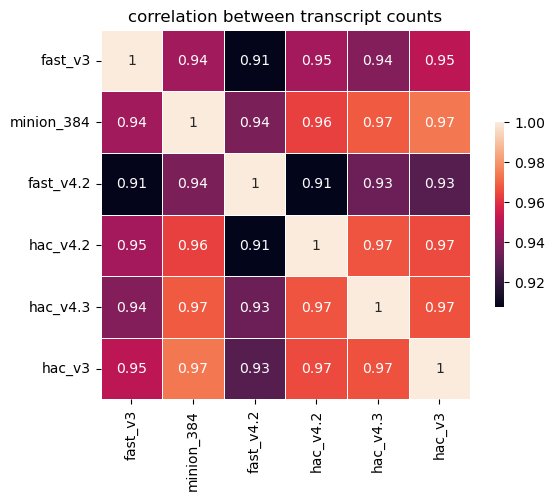

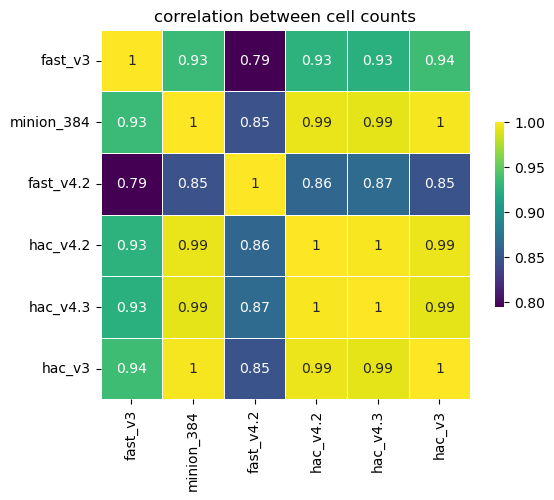

In [11]:
# shows the correlation between different sequencing runs at the cell count and gene count levels

sns.heatmap(
    adata.var.corr(),
    square=True,
    annot=True,
    linewidth=0.5,
    cbar_kws={'shrink' : 0.5,},
)

plt.title("correlation between transcript counts")
plt.show()

sns.heatmap(
    adata.obs.corr(),
    square=True,
    annot=True,
    linewidth=0.5,
    cbar_kws={'shrink' : 0.5,},
    cmap='viridis',
)

plt.title("correlation between cell counts")
plt.show()

# Load and Filter GTF Features

In [4]:
adata.var.head()

,fast_v3,minion_384,fast_v4.2,hac_v4.2,hac_v4.3,hac_v3
ENST00000000233,21.0,494.0,36.0,5077.0,1104.0,1621.0
ENST00000000412,0.0,102.0,17.0,668.0,347.0,992.0
ENST00000000442,0.0,0.0,0.0,178.0,0.0,0.0
ENST00000001008,4.0,124.0,5.0,1162.0,190.0,66.0
ENST00000002125,0.0,41.0,3.0,161.0,30.0,215.0


In [22]:
# --- Load and Process Gene Annotation Data (GTF) ---

print("Starting GTF processing...")

# Define the path to the Gene Transfer Format (GTF) file.
# This file contains gene and transcript annotations.
gtf_path = "/nfs/turbo/umms-indikar/shared/projects/reference_genome/prebuilt/refdata-gex-GRCh38-2024-A/genes/genes.gtf"
print(f"Reading GTF file from: {gtf_path}")

# Read the GTF file using pyranges and convert it into a pandas DataFrame.
gtf_raw = pr.read_gtf(gtf_path)
gtf_raw = gtf_raw.as_df()
print(f"Raw GTF loaded. Shape: {gtf_raw.shape}")

# --- Filter GTF Data for Relevant Transcripts ---

# Create a copy to avoid modifying the original raw GTF DataFrame.
gdf = gtf_raw.copy()
print(f"Initial number of GTF entries: {len(gdf)}")

# Filter 1: Keep only entries that represent 'transcript' features.
gdf = gdf[gdf['Feature'] == 'transcript']
print(f"Number of entries after filtering for 'transcript' features: {len(gdf)}")

# Filter 2: Keep only transcripts whose IDs are present in the AnnData object's variable names (adata.var_names).
# This ensures the annotation matches the expression data.
# Note: Ensure adata.var_names contains transcript IDs.
if 'adata' in locals() or 'adata' in globals():
    print(f"Filtering transcripts based on {len(adata.var_names)} variables in AnnData object...")
    gdf = gdf[gdf['transcript_id'].isin(adata.var_names)]
    print(f"Number of entries after matching with AnnData variables: {len(gdf)}")
else:
    print("Warning: AnnData object 'adata' not found. Skipping filtering based on adata.var_names.")


# --- Select and Clean Relevant Annotation Columns ---

# Define the specific columns we want to keep for transcript annotation.
keep_columns = [
    'gene_id',
    'gene_name',
    'gene_type',
    'transcript_id',
    'transcript_name',
    'transcript_type',
    'Chromosome',
    'Start',
    'End',
]
print(f"Selecting specific columns: {', '.join(keep_columns)}")

# Select only the desired columns.
gdf = gdf[keep_columns]

# Remove duplicate rows based on the selected columns.
# Often, GTF files have redundant entries for the same transcript feature.
initial_rows = len(gdf)
gdf = gdf.drop_duplicates()
print(f"Removed {initial_rows - len(gdf)} duplicate rows based on selected columns.")

# Remove any rows where 'transcript_id' is missing (NaN).
initial_rows = len(gdf)
gdf = gdf[gdf['transcript_id'].notna()]
print(f"Removed {initial_rows - len(gdf)} rows with missing 'transcript_id'.")

# Reset the DataFrame index for a clean, sequential index.
gdf = gdf.reset_index(drop=True)

# --- Final Processed GTF DataFrame ---

print(f"Final processed transcript annotation DataFrame shape: {gdf.shape}")
print("Showing the first few rows of the final transcript annotation DataFrame:")
# Display the first few rows of the cleaned DataFrame.
print(gdf.head())

Starting GTF processing...
Reading GTF file from: /nfs/turbo/umms-indikar/shared/projects/reference_genome/prebuilt/refdata-gex-GRCh38-2024-A/genes/genes.gtf
Raw GTF loaded. Shape: (3293161, 27)
Initial number of GTF entries: 3293161
Number of entries after filtering for 'transcript' features: 226005
Filtering transcripts based on 82250 variables in AnnData object...
Number of entries after matching with AnnData variables: 82250
Selecting specific columns: gene_id, gene_name, gene_type, transcript_id, transcript_name, transcript_type, Chromosome, Start, End
Removed 0 duplicate rows based on selected columns.
Removed 0 rows with missing 'transcript_id'.
Final processed transcript annotation DataFrame shape: (82250, 9)
Showing the first few rows of the final transcript annotation DataFrame:
           gene_id        gene_name       gene_type    transcript_id  \
0  ENSG00000277400  ENSG00000277400  protein_coding  ENST00000613230   
1  ENSG00000274847            MAFIP  protein_coding  ENS

# Merge in Transcript Annotations

1.  **Add Transcript Details:** Combines detailed information about each transcript (like its corresponding gene name) from `gdf` into the main data's variable table (`adata.var`).
2.  **Sum Counts per Gene:** Calculates the total expression count for each gene by summing the counts of all transcripts belonging to that gene. This gene-level summary is stored as `X_gene`.

In [23]:
print("Merging transcript annotations (gdf) into adata.var...")

# Update adata.var by adding columns from the processed GTF DataFrame (gdf).
# pd.concat is used to join the two DataFrames horizontally (axis=1).
# gdf.set_index('transcript_id') ensures gdf is indexed by transcript ID before joining,
# aligning its rows with the corresponding transcript IDs in adata.var's index.
# Any columns present in both DataFrames will result in suffixed column names if not identical,
# but typically gdf contains new annotation columns to be added.
adata.var = pd.concat([
    adata.var,                   # The existing variable annotation DataFrame (indexed by transcript_id).
    gdf.set_index('transcript_id') # The new annotation DataFrame (gdf), indexed by transcript_id for alignment.
], axis=1) 

print("Transcript annotations successfully merged into adata.var.")

# --- Aggregate Transcript Counts to Gene Level ---

print("Aggregating transcript counts to gene level...")

# Use scanpy's aggregate function to sum expression values.
# This groups transcripts belonging to the same gene and sums their counts for each observation (cell).
aggdata = sc.get.aggregate(
    adata,            # The AnnData object with transcript-level data.
    by='gene_name',   # Group variables (axis=1) based on the 'gene_name' column in adata.var.
    func='sum',       # The aggregation function to apply (summing counts within each gene group).
    axis=1,           # Specify aggregation along the variable axis (axis=1, columns).
)

# --- Extract Aggregated Data and Add to AnnData ---

# The result 'aggdata' is a small AnnData object where variables are now genes.
# Extract the aggregated counts (stored in the 'sum' layer by default) into a pandas DataFrame.
# The resulting DataFrame 'X_gene' has observations (cells) as rows and genes as columns.
X_gene = aggdata.to_df(layer='sum')
print(f"Shape of aggregated gene expression matrix (observations x genes): {X_gene.shape}")

# Store the newly created gene-level expression matrix ('X_gene')
# into the original AnnData object's '.obsm' attribute.
# '.obsm' is used for storing multidimensional observation-based annotations.
adata.obsm['X_gene'] = X_gene
print("Gene-level expression matrix added to adata.obsm['X_gene']")

# Display the updated AnnData object summary (optional, often done in notebooks).
# This will now show 'X_gene' listed under 'obsm'.
print("\nUpdated AnnData object summary:")
print(adata)

,fast_v3,minion_384,fast_v4.2,hac_v4.2,hac_v4.3,hac_v3,gene_id,gene_name,gene_type,transcript_name,transcript_type,Chromosome,Start,End
ENST00000000233,21.0,494.0,36.0,5077.0,1104.0,1621.0,ENSG00000004059,ARF5,protein_coding,ARF5-201,protein_coding,chr7,127588410,127591700
ENST00000000412,0.0,102.0,17.0,668.0,347.0,992.0,ENSG00000003056,M6PR,protein_coding,M6PR-201,protein_coding,chr12,8940360,8949645
ENST00000000442,0.0,0.0,0.0,178.0,0.0,0.0,ENSG00000173153,ESRRA,protein_coding,ESRRA-201,protein_coding,chr11,64305523,64316743
ENST00000001008,4.0,124.0,5.0,1162.0,190.0,66.0,ENSG00000004478,FKBP4,protein_coding,FKBP4-201,protein_coding,chr12,2794969,2805423
ENST00000002125,0.0,41.0,3.0,161.0,30.0,215.0,ENSG00000003509,NDUFAF7,protein_coding,NDUFAF7-201,protein_coding,chr2,37231657,37249160
